**อัพโหลดไฟล์**

In [5]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings_CLEANED_MODEL.xlsx to hotel_bookings_CLEANED_MODEL (1).xlsx


**หาโมเดลที่เหมาะสมกับข้อมูล**

In [31]:
print("===== DATASET MODEL CHECK =====")

# 1. ขนาดข้อมูล
print("\n[1] Dataset shape")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# 2. ตรวจ Target
print("\n[2] Target: is_canceled")
print(df["is_canceled"].value_counts())
print("\nสัดส่วน:")
print(df["is_canceled"].value_counts(normalize=True))

# 3. จำนวนคลาส
n_classes = df["is_canceled"].nunique()

print("\n[3] Number of classes:", n_classes)

if n_classes == 2:
    print("ประเภทปัญหา: Binary Classification")
elif n_classes > 2:
    print("ประเภทปัญหา: Multiclass Classification")
else:
    print("กรุณาตรวจสอบ Target")

# 4. ตรวจชนิดข้อมูลของ Features
print("\n[4] Feature types")

for col in features:
    print(col, "->", df[col].dtype)

# 5. ตรวจ Missing
print("\n[5] Missing values")
print(df[features + [target]].isnull().sum())

# 6. ตรวจความสมดุลของ Target
class_ratio = df[target].value_counts(normalize=True)

print("\n[6] Class balance")

for cls, ratio in class_ratio.items():
    print(f"Class {cls}: {ratio:.2%}")

# 7. สรุปเบื้องต้น
print("\n===== RECOMMENDATION =====")

if n_classes == 2:
    print("✓ เหมาะกับโมเดล Classification")
    print("✓ สามารถทดลอง Logistic Regression")
    print("✓ สามารถทดลอง Random Forest")
    print("✓ สามารถทดลอง Decision Tree")
    print("✓ สามารถทดลอง Gradient Boosting / XGBoost")

===== DATASET MODEL CHECK =====

[1] Dataset shape
Rows: 87230
Columns: 32

[2] Target: is_canceled
is_canceled
0    63221
1    24009
Name: count, dtype: int64

สัดส่วน:
is_canceled
0    0.724762
1    0.275238
Name: proportion, dtype: float64

[3] Number of classes: 2
ประเภทปัญหา: Binary Classification

[4] Feature types
lead_time -> int64
adr -> float64
total_of_special_requests -> int64
hotel -> object
market_segment -> object
deposit_type -> object

[5] Missing values
lead_time                    0
adr                          0
total_of_special_requests    0
hotel                        0
market_segment               0
deposit_type                 0
is_canceled                  0
dtype: int64

[6] Class balance
Class 0: 72.48%
Class 1: 27.52%

===== RECOMMENDATION =====
✓ เหมาะกับโมเดล Classification
✓ สามารถทดลอง Logistic Regression
✓ สามารถทดลอง Random Forest
✓ สามารถทดลอง Decision Tree
✓ สามารถทดลอง Gradient Boosting / XGBoost


**โมเดลที่เหมาะสมกับชุดข้อมูล จากผล ROC-AUC**

In [32]:
# ==========================================
# MODEL COMPARISON
# หาว่าโมเดลไหนเหมาะกับ Dataset ของเรา
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
import time


# ------------------------------------------
# 1. เตรียม Preprocessing
# ------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


# ------------------------------------------
# 2. กำหนดโมเดลที่ต้องการเปรียบเทียบ
# ------------------------------------------

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    )
}


# ------------------------------------------
# 3. Train + Evaluate ทุกโมเดล
# ------------------------------------------

results = []

trained_models = {}

for name, model in models.items():

    print(f"กำลังทดสอบ: {name}")

    start_time = time.time()

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Time (sec)": time.time() - start_time
    })

    trained_models[name] = pipeline


# ------------------------------------------
# 4. สร้างตารางเปรียบเทียบ
# ------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)


print("\n==========================================")
print("MODEL COMPARISON")
print("==========================================")

display(results_df.round(4))


# ------------------------------------------
# 5. ระบุโมเดลที่เหมาะสมที่สุด
# ------------------------------------------

best_model = results_df.iloc[0]["Model"]
best_auc = results_df.iloc[0]["ROC-AUC"]

print("\n==========================================")
print("ผลการเลือกโมเดล")
print("==========================================")

print(f"โมเดลที่เหมาะสมที่สุดจากการทดสอบ: {best_model}")
print(f"ROC-AUC: {best_auc:.4f}")

print("\nเหตุผล:")
print("เลือกจาก ROC-AUC ที่สูงที่สุดบนชุด Test Data")

กำลังทดสอบ: Logistic Regression
กำลังทดสอบ: Decision Tree
กำลังทดสอบ: Random Forest
กำลังทดสอบ: Gradient Boosting

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Time (sec)
0,Random Forest,0.7178,0.4914,0.7234,0.5852,0.7938,21.0252
1,Gradient Boosting,0.7869,0.6763,0.4329,0.5279,0.7914,26.9908
2,Decision Tree,0.7184,0.4917,0.6791,0.5704,0.7702,1.1244
3,Logistic Regression,0.6794,0.4475,0.7018,0.5465,0.7504,1.6273



ผลการเลือกโมเดล
โมเดลที่เหมาะสมที่สุดจากการทดสอบ: Random Forest
ROC-AUC: 0.7938

เหตุผล:
เลือกจาก ROC-AUC ที่สูงที่สุดบนชุด Test Data


**อ่าน Excel**

In [8]:
import pandas as pd
import numpy as np

file_path = "/content/hotel_bookings_CLEANED_MODEL (1).xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Cleaned_Model_Data"
)

print("โหลดข้อมูลสำเร็จ")
print("จำนวนแถว:", len(df))
print("จำนวนคอลัมน์:", len(df.columns))

โหลดข้อมูลสำเร็จ
จำนวนแถว: 87230
จำนวนคอลัมน์: 32


**ตรวจสอบดูข้อมูล 5 แถวแรก**

In [9]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304,0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240,0,0,Transient,98.0,0,1,Check-Out,2015-07-03


**เลือกตัวแปรสำหรับโมเดล**

In [10]:
numeric_features = [
    "lead_time",
    "adr",
    "total_of_special_requests"
]

categorical_features = [
    "hotel",
    "market_segment",
    "deposit_type"
]

target = "is_canceled"

print("ตัวเลข:", numeric_features)
print("ตัวหนังสือ:", categorical_features)
print("Target:", target)

ตัวเลข: ['lead_time', 'adr', 'total_of_special_requests']
ตัวหนังสือ: ['hotel', 'market_segment', 'deposit_type']
Target: is_canceled


**แยก X กับ y**

In [12]:
features = numeric_features + categorical_features

X = df[features]
y = df[target]

print("X:", X.shape)
print("y:", y.shape)

X: (87230, 6)
y: (87230,)


**ตรวจ Target (is_canceled)**

In [13]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True))

is_canceled
0    63221
1    24009
Name: count, dtype: int64

is_canceled
0    0.724762
1    0.275238
Name: proportion, dtype: float64


**แบ่งข้อมูล Train / Test**

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (69784, 6)
Testing data: (17446, 6)


**เตรียมข้อมูลก่อนเข้าโมเดล**

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("เตรียมข้อมูลสำหรับโมเดลเรียบร้อยแล้ว")

เตรียมข้อมูลสำหรับโมเดลเรียบร้อยแล้ว


**สร้าง Logistic Regression**

In [16]:
from sklearn.linear_model import LogisticRegression

model_lr = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

print("สร้าง Logistic Regression เรียบร้อยแล้ว")

สร้าง Logistic Regression เรียบร้อยแล้ว


**Train โมเดล Logistic Regression**

In [17]:
model_lr.fit(X_train, y_train)

print("Logistic Regression เรียนรู้เสร็จแล้ว")

Logistic Regression เรียนรู้เสร็จแล้ว


**ให้โมเดล Logistic Regression ทำนายข้อมูล Test**

In [18]:
y_pred_lr = model_lr.predict(X_test)

print(y_pred_lr[:20])

[0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 0 0 0 0 0]


**วัดประสิทธิภาพ Logistic Regression**

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.679410753181245
Precision: 0.4474837338998805
Recall   : 0.7017909204498126
F1-score : 0.546501256790724
ROC-AUC  : 0.7504244563684249


**สร้าง Random Forest**

In [20]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    )
])

print("สร้าง Random Forest เรียบร้อยแล้ว")

สร้าง Random Forest เรียบร้อยแล้ว


**Train Random Forest**

In [21]:
model_rf.fit(X_train, y_train)

print("Random Forest เรียนรู้เสร็จแล้ว")

Random Forest เรียนรู้เสร็จแล้ว


**ให้ Random Forest ทำนายข้อมูล Test**

In [22]:
y_pred_rf = model_rf.predict(X_test)

print(y_pred_rf[:20])

[0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0]


**วัดประสิทธิภาพ Random Forest**

In [23]:
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.7497993809469219
Precision: 0.5523353293413173
Recall   : 0.48021657642648896
F1-score : 0.5137573799710371
ROC-AUC  : 0.7494285901384811


**ทำตารางเปรียบเทียบใน Colab**

In [24]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6794,0.4475,0.7018,0.5465,0.7504
1,Random Forest,0.7498,0.5523,0.4802,0.5138,0.7494


**Confusion Matrix Logistic Regression**

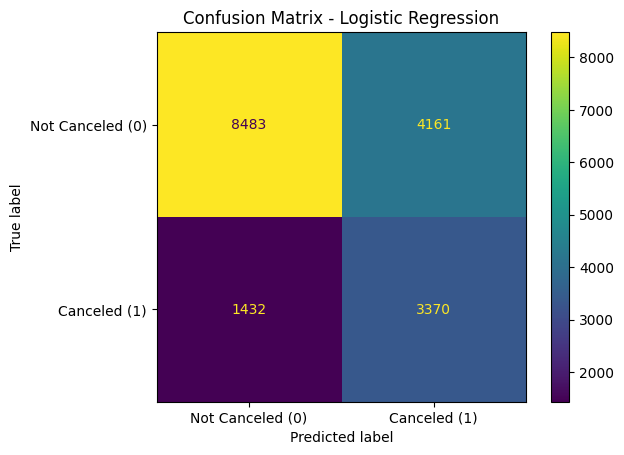

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Not Canceled (0)", "Canceled (1)"]
)

disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

**Confusion Matrix Random Forest**

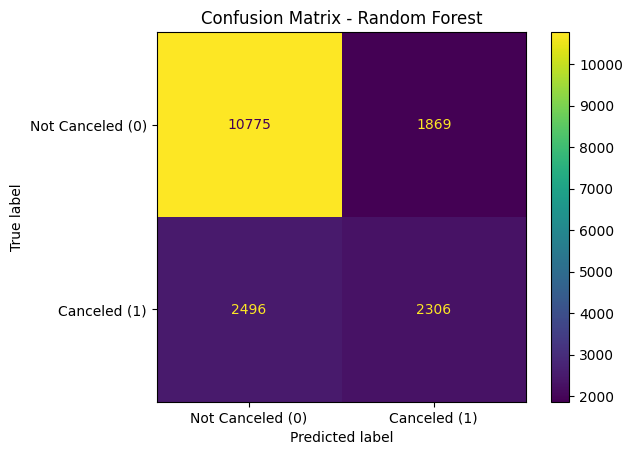

In [27]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not Canceled (0)", "Canceled (1)"]
)

disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

**เปรียบเทียบ ROC Curve**

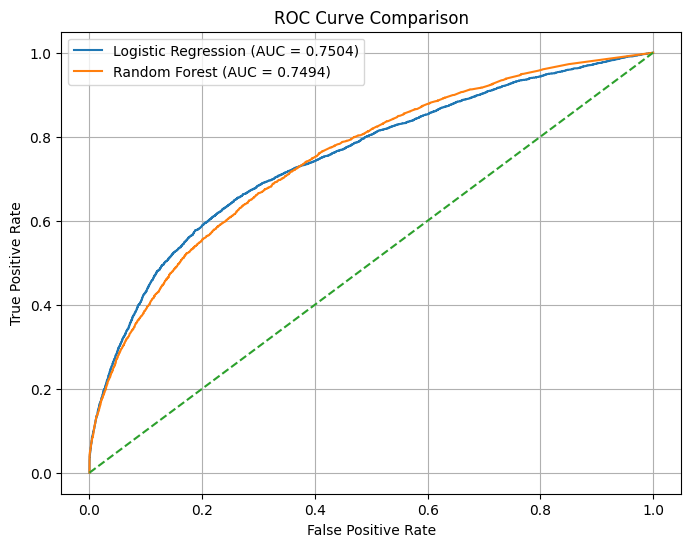

In [26]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# คำนวณ ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# วาดกราฟ
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.4f})"
)

# เส้นอ้างอิง
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

**Feature Importance**

In [28]:
# ดึงชื่อ Feature หลังจาก One-Hot Encoding
feature_names = model_rf.named_steps["preprocessor"].get_feature_names_out()

# ดึงค่า Feature Importance จาก Random Forest
importances = model_rf.named_steps["model"].feature_importances_

# สร้าง DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# เรียงจากมากไปน้อย
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# แสดง 15 อันดับแรก
feature_importance.head(15)

,Feature,Importance
1,num__adr,0.438960
0,num__lead_time,0.396812
2,num__total_of_special_requests,0.057966
11,cat__market_segment_Online TA,0.044925
14,cat__deposit_type_Non Refund,0.015514
10,cat__market_segment_Offline TA/TO,0.015074
13,cat__deposit_type_No Deposit,0.010222
8,cat__market_segment_Direct,0.007028
9,cat__market_segment_Groups,0.004224
4,cat__hotel_Resort Hotel,0.002766


**ทำกราฟ Feature Importance**

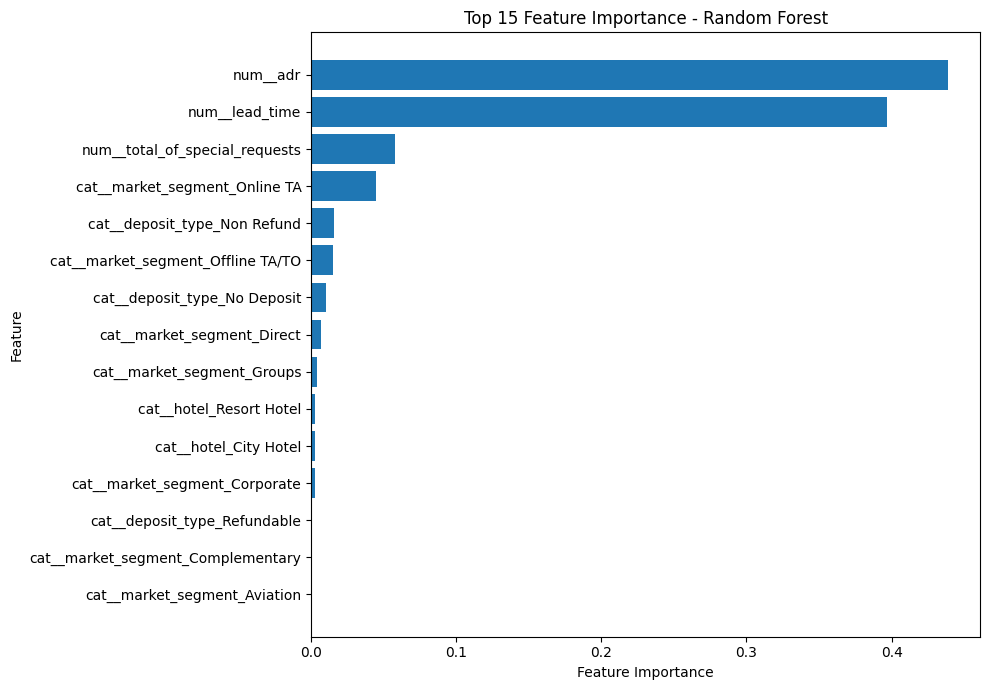

In [29]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

**ตารางสรุปผลทั้งหมด**

In [30]:
summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

summary = summary.round(4)

summary

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.6794,0.4475,0.7018,0.5465,0.7504
1,Random Forest,0.7498,0.5523,0.4802,0.5138,0.7494


In [12]:
import pandas as pd

file_path = "/hotel_bookings_CLEANED_MODEL.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Cleaned_Model_Data"
)

print("โหลดข้อมูลสำเร็จ!")
print("จำนวนแถว:", len(df))
print("จำนวนคอลัมน์:", len(df.columns))
print("ขนาดข้อมูล:", df.shape)

โหลดข้อมูลสำเร็จ!
จำนวนแถว: 87230
จำนวนคอลัมน์: 32
ขนาดข้อมูล: (87230, 32)


In [13]:
df.to_csv(
    "/content/hotel_bookings.csv",
    index=False,
    encoding="utf-8-sig"
)

print("สร้าง CSV สำเร็จ!")

สร้าง CSV สำเร็จ!


In [14]:
print("จำนวนแถว:", len(df))
print("จำนวนคอลัมน์:", len(df.columns))

print("\nชื่อคอลัมน์:")
print(df.columns.tolist())

print("\nตัวอย่างข้อมูล:")
display(df.head())

จำนวนแถว: 87230
จำนวนคอลัมน์: 32

ชื่อคอลัมน์:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

ตัวอย่างข้อมูล:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304,0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240,0,0,Transient,98.0,0,1,Check-Out,2015-07-03
